<a href="https://colab.research.google.com/github/janecekhwt-sys/MML1-project-HW2/blob/main/Neural_networks_komplexni_evaluace_hw04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# rozpracované_nedokončené

## HW4 - Neuronové sítě
# 1. Úvod

Cílem tohoto úkolu je ověřit možnosti využití neuronových sítí pro predikci inflace v České republice. Na rozdíl od předchozího úkolu, kde byly použity klasické metody strojového učení, budou nyní testovány dvě architektury neuronových sítí vhodné pro časové řady – LSTM (Long Short-Term Memory) a GRU (Gated Recurrent Unit).

Oba modely patří mezi rekurentní neuronové sítě a jsou navrženy pro práci se sekvenčními daty, kde budoucí hodnoty závisí na minulém vývoji. Cílem je porovnat jejich predikční schopnost a vyhodnotit, zda dokáží překonat nejlepší modely z předchozího úkolu.

## 1. Import knihoven

Použité modely zahrnují naivní baseline model z HW2, referenční model Ridge Regression z HW3 a dvě rekurentní neuronové sítě (LSTM a GRU), které jsou vhodné pro predikci časových řad.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

import torch
import torch.nn as nn
import torch.optim as optim

import time
import copy

from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

## 2. Načtení připravených dat

Data byla připravena v notebooku `dataprocessing.ipynb`. Tento notebook již vytvořil soubory `data/train.csv`, `data/validation.csv` a `data/test.csv`.

Rozdělení je časové, nikoliv náhodné.

In [81]:
!rm -rf MML1-project-HW2
!git clone https://github.com/janecekhwt-sys/MML1-project-HW2.git
train = pd.read_csv(
    "MML1-project-HW2/data/train.csv",
    parse_dates=["date"],
    index_col="date"
)

valid = pd.read_csv(
    "MML1-project-HW2/data/validation.csv",
    parse_dates=["date"],
    index_col="date"
)

test = pd.read_csv(
    "MML1-project-HW2/data/test.csv",
    parse_dates=["date"],
    index_col="date"
)

print("Train:", train.shape, train.index.min(), "až", train.index.max())
print("Validation:", valid.shape, valid.index.min(), "až", valid.index.max())
print("Test:", test.shape, test.index.min(), "až", test.index.max())

Cloning into 'MML1-project-HW2'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 141 (delta 66), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 6.36 MiB | 11.09 MiB/s, done.
Resolving deltas: 100% (66/66), done.
Train: (75, 7) 1997-06-30 00:00:00 až 2015-12-31 00:00:00
Validation: (20, 7) 2016-03-31 00:00:00 až 2020-12-31 00:00:00
Test: (19, 7) 2021-03-31 00:00:00 až 2025-09-30 00:00:00


## 3. Kontrola sloupců a definice proměnných

Používám stejné vstupní proměnné jako v původním benchmarku:

- `infl_de` – inflace v Německu
- `rate` – úroková sazba
- `oil` – cena ropy
- `gdp_growth` – růst HDP ČR

Cílová proměnná je `target`.

In [82]:
print("Sloupce v train datasetu:")
print(train.columns.tolist())

features = ["infl_de", "rate", "oil", "gdp_growth"]
target = "target"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

print("\nPoužité vstupní proměnné:", features)
print("Cílová proměnná:", target)

Sloupce v train datasetu:
['infl_cz', 'infl_de', 'rate', 'oil', 'gdp_growth', 'target', 'baseline']

Použité vstupní proměnné: ['infl_de', 'rate', 'oil', 'gdp_growth']
Cílová proměnná: target


## 4. Poznámka k baseline modelu

V datech už je připravený sloupec `baseline`.


In [83]:
print("Ukázka původní baseline z datasetu:")
display(test[["infl_cz", "target", "baseline"]].head())

Ukázka původní baseline z datasetu:


,infl_cz,target,baseline
date,,,
2021-03-31,2.168025,2.760375,2.700482
2021-06-30,2.760375,3.273442,2.168025
2021-09-30,3.273442,5.019695,2.760375
2021-12-31,5.019695,10.225083,3.273442
2022-03-31,10.225083,15.029760,5.019695


## 5. Standardizace vstupních proměnných

In [84]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)
print(X_valid_scaled.shape)
print(X_test_scaled.shape)

(75, 4)
(20, 4)
(19, 4)


## 5. Pomocná funkce pro výpočet metrik

Protože jde o regresní úlohu, používám metriky MAE, RMSE a R².

In [85]:
def regression_metrics(y_true, y_pred):
    """Vrátí základní metriky pro regresní model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

## 6. Příprava sekvenčních dat

In [86]:
## 6. Příprava sekvenčních dat

SEQ_LEN = 4

def create_sequences(X, y, seq_len):

    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):

        X_seq.append(
            X[i:i+seq_len]
        )

        y_seq.append(
            y.iloc[i+seq_len]
        )

    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train,
    SEQ_LEN
)

X_valid_seq, y_valid_seq = create_sequences(
    X_valid_scaled,
    y_valid,
    SEQ_LEN
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test,
    SEQ_LEN
)

print("Train:", X_train_seq.shape)
print("Validation:", X_valid_seq.shape)
print("Test:", X_test_seq.shape)

Train: (71, 4, 4)
Validation: (16, 4, 4)
Test: (15, 4, 4)


## 7. Příprava dat pro PyTorch



In [87]:
class TimeSeriesDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)

valid_dataset = TimeSeriesDataset(X_valid_seq, y_valid_seq)

test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

for X_batch, y_batch in train_loader:

    print(X_batch.shape)
    print(y_batch.shape)

    break

torch.Size([8, 4, 4])
torch.Size([8])


## 8. Definice modelu LSTM

In [88]:
class LSTMRegressor(nn.Module):

    def __init__(self,
                 input_size,
                 hidden_size=32,
                 num_layers=1):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]      # poslední časový krok

        out = self.fc(out)

        return out.squeeze()


lstm_model = LSTMRegressor(
    input_size=4,
    hidden_size=32
)

print(lstm_model)

LSTMRegressor(
  (lstm): LSTM(4, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## 9. Trénování modelu LSTM

In [89]:
# Loss funkce a optimizer

criterion = nn.MSELoss()

optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [90]:
# trénovací funkce



def train_model(model,
                train_loader,
                valid_loader,
                criterion,
                optimizer,
                epochs=100,
                patience=5):

    train_losses = []
    valid_losses = []

    best_valid_loss = float("inf")
    best_epoch = 0
    best_model_state = None

    patience_counter = 0

    for epoch in range(epochs):

        # TRAIN
        model.train()
        running_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            prediction = model(X_batch)
            loss = criterion(prediction, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # VALIDATION
        model.eval()
        running_loss = 0

        with torch.no_grad():

            for X_batch, y_batch in valid_loader:

                prediction = model(X_batch)
                loss = criterion(prediction, y_batch)

                running_loss += loss.item()

        valid_loss = running_loss / len(valid_loader)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        # EARLY STOPPING
        if valid_loss < best_valid_loss:

            best_valid_loss = valid_loss
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

        else:

            patience_counter += 1

        if (epoch + 1) % 3 == 0:

            print(
                f"Epoch {epoch+1:3d} | "
                f"Train: {train_loss:.4f} | "
                f"Valid: {valid_loss:.4f}"
            )

        if patience_counter >= patience:

            print(f"\nEarly stopping v epoše {epoch+1}")
            break

    # obnovení nejlepších vah
    model.load_state_dict(best_model_state)

    print(f"Nejlepší validační chyba: {best_valid_loss:.4f}")
    print(f"Nejlepší epocha: {best_epoch}")

    return train_losses, valid_losses, best_valid_loss, best_epoch

In [91]:
# Spuštění trénování

start_time = time.perf_counter()

train_losses, valid_losses, lstm_best_valid_loss, lstm_best_epoch = train_model(
    lstm_model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    epochs=100,
    patience=10
)

end_time = time.perf_counter()

lstm_training_time = end_time - start_time

print(f"\nDoba trénování LSTM: {training_time:.2f} s")

Epoch   3 | Train: 8.7906 | Valid: 6.6410
Epoch   6 | Train: 7.4345 | Valid: 5.1313
Epoch   9 | Train: 4.4832 | Valid: 1.9906
Epoch  12 | Train: 3.2648 | Valid: 0.5753
Epoch  15 | Train: 3.0824 | Valid: 0.6669
Epoch  18 | Train: 2.9640 | Valid: 0.7624
Epoch  21 | Train: 2.8333 | Valid: 0.7775

Early stopping v epoše 22
Nejlepší validační chyba: 0.5753
Nejlepší epocha: 12

Doba trénování LSTM: 1.00 s


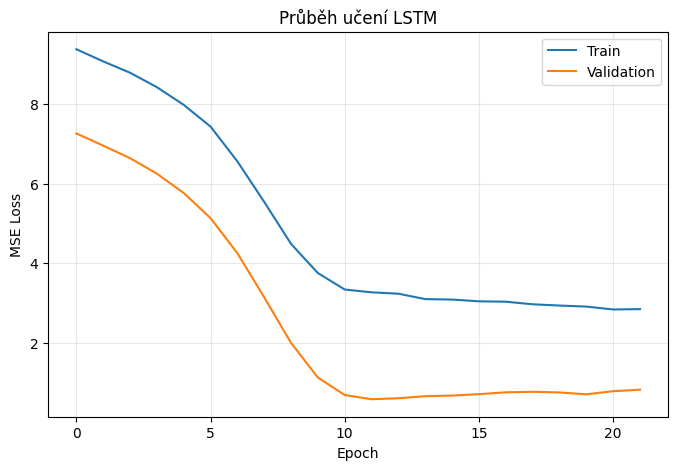

In [92]:
# graf učení

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train")

plt.plot(valid_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("Průběh učení LSTM")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## 10. Vyhodnocení modelu LSTM

In [93]:
lstm_model.eval()

lstm_predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = lstm_model(X_batch)

        lstm_predictions.extend(pred.numpy())

lstm_predictions = np.array(lstm_predictions)

In [94]:
# Spočítání metrik

lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_seq, lstm_predictions)
lstm_r2 = r2_score(y_test_seq, lstm_predictions)

print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE : {lstm_mae:.4f}")
print(f"R²  : {lstm_r2:.4f}")

RMSE: 7.5777
MAE : 5.3130
R²  : -0.4966


In [95]:
# Predikce LSTM na testovací sadě

lstm_model.eval()

predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = lstm_model(X_batch)

        predictions.extend(pred.numpy())

predictions = np.array(predictions)

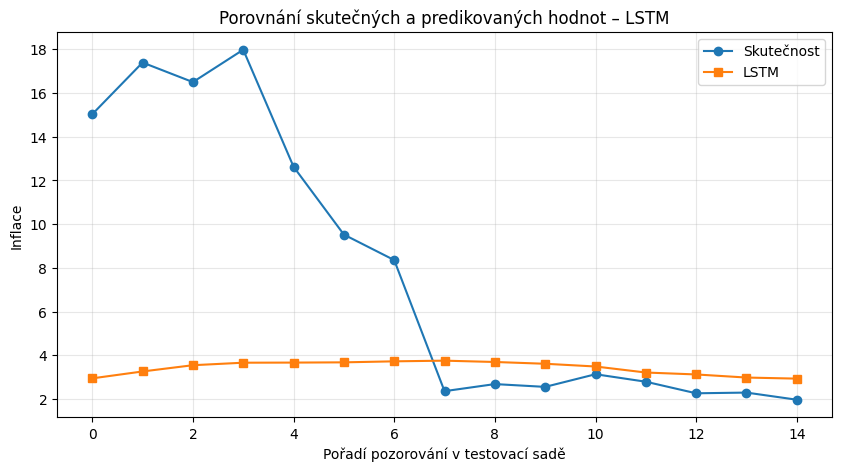

In [96]:
# graf skutečnost vs. predikce pro LSTM

plt.figure(figsize=(10,5))

plt.plot(y_test_seq, marker="o", label="Skutečnost")
plt.plot(lstm_predictions, marker="s", label="LSTM")

plt.title("Porovnání skutečných a predikovaných hodnot – LSTM")
plt.xlabel("Pořadí pozorování v testovací sadě")
plt.ylabel("Inflace")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## 11. Definice modelu GRU

In [97]:
class GRURegressor(nn.Module):

    def __init__(self,
                 input_size,
                 hidden_size=32,
                 num_layers=1):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.gru(x)

        out = out[:, -1, :]      # poslední časový krok

        out = self.fc(out)

        return out.squeeze()

In [98]:
gru_model = GRURegressor(
    input_size=4,
    hidden_size=32
)

print(gru_model)

GRURegressor(
  (gru): GRU(4, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


# 12. Trénování modelu GRU

In [99]:
# Trénování GRU

criterion = nn.MSELoss()

gru_optimizer = optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

In [100]:
# Spuštění trénování GRU

start_time = time.perf_counter()

gru_train_losses, gru_valid_losses, gru_best_valid_loss, gru_best_epoch = train_model(
    gru_model,
    train_loader,
    valid_loader,
    criterion,
    gru_optimizer,
    epochs=100,
    patience=20
)

end_time = time.perf_counter()

gru_training_time = end_time - start_time

print(f"\nDoba trénování GRU: {gru_training_time:.2f} s")
print(f"Nejlepší epocha: {gru_best_epoch}")
print(f"Nejlepší validační chyba: {gru_best_valid_loss:.4f}")

Epoch   3 | Train: 8.4587 | Valid: 5.7578
Epoch   6 | Train: 7.0435 | Valid: 4.3546
Epoch   9 | Train: 4.4618 | Valid: 1.7356
Epoch  12 | Train: 3.2502 | Valid: 0.4391
Epoch  15 | Train: 2.9982 | Valid: 0.7818
Epoch  18 | Train: 2.8100 | Valid: 0.8751
Epoch  21 | Train: 2.6880 | Valid: 0.9304
Epoch  24 | Train: 2.5796 | Valid: 1.0049
Epoch  27 | Train: 2.4208 | Valid: 1.1954
Epoch  30 | Train: 2.3462 | Valid: 1.2667

Early stopping v epoše 32
Nejlepší validační chyba: 0.4391
Nejlepší epocha: 12

Doba trénování GRU: 0.72 s
Nejlepší epocha: 12
Nejlepší validační chyba: 0.4391


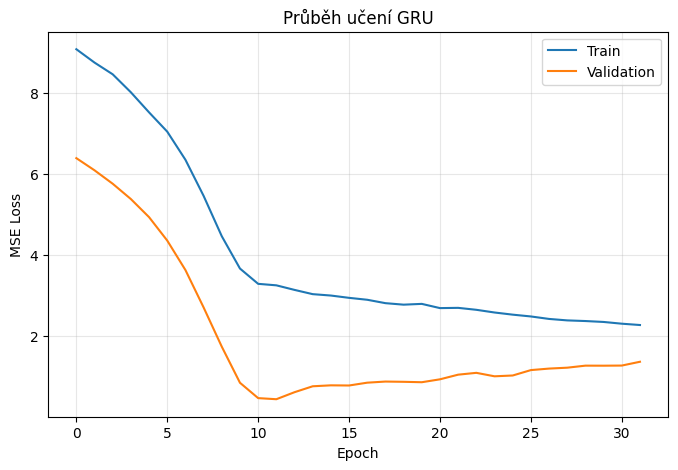

In [101]:
# Graf učení GRU

plt.figure(figsize=(8,5))

plt.plot(gru_train_losses, label="Train")
plt.plot(gru_valid_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Průběh učení GRU")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [102]:
gru_rmse = np.sqrt(mean_squared_error(y_test_seq, gru_predictions))
gru_mae = mean_absolute_error(y_test_seq, gru_predictions)
gru_r2 = r2_score(y_test_seq, gru_predictions)

print(f"RMSE: {gru_rmse:.4f}")
print(f"MAE : {gru_mae:.4f}")
print(f"R²  : {gru_r2:.4f}")

RMSE: 7.7755
MAE : 5.4096
R²  : -0.5757


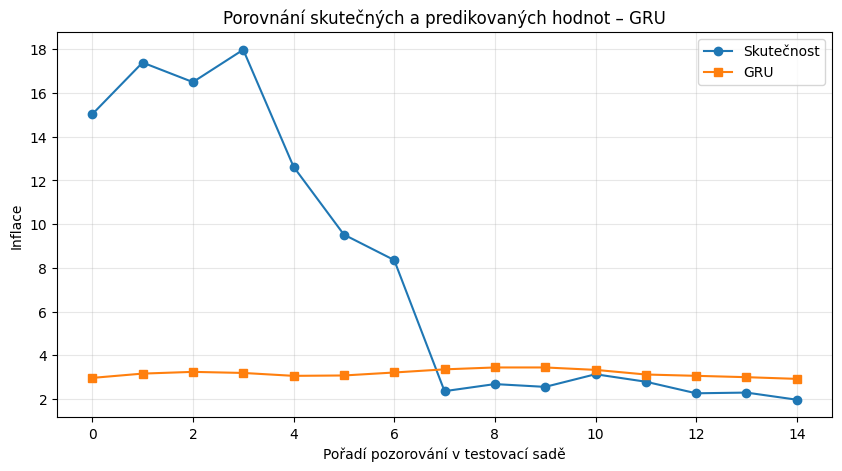

In [103]:
plt.figure(figsize=(10,5))

plt.plot(y_test_seq,
         marker="o",
         label="Skutečnost")

plt.plot(gru_predictions,
         marker="s",
         label="GRU")

plt.title("Porovnání skutečných a predikovaných hodnot – GRU")

plt.xlabel("Pořadí pozorování v testovací sadě")

plt.ylabel("Inflace")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

# 13. Vyhodnocení modelu GRU

In [104]:
gru_model.eval()

gru_predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = gru_model(X_batch)

        gru_predictions.extend(pred.numpy())

gru_predictions = np.array(gru_predictions)

In [105]:
# Provnání modelů

# Férové porovnání na stejné části testovací sady jako LSTM/GRU

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# cílové hodnoty pro sekvenční modely
y_test_aligned = y_test_seq

# baseline z HW2 zarovnaná na stejný úsek
baseline_pred_aligned = test["baseline"].iloc[SEQ_LEN:].values

baseline_rmse = np.sqrt(mean_squared_error(y_test_aligned, baseline_pred_aligned))
baseline_mae = mean_absolute_error(y_test_aligned, baseline_pred_aligned)
baseline_r2 = r2_score(y_test_aligned, baseline_pred_aligned)

# Ridge model z HW3, ale predikce pouze na stejném úseku testu
start_time = time.perf_counter()

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred_aligned = ridge_model.predict(
    X_test.iloc[SEQ_LEN:]
)

ridge_training_time = time.perf_counter() - start_time

ridge_rmse = np.sqrt(mean_squared_error(y_test_aligned, ridge_pred_aligned))
ridge_mae = mean_absolute_error(y_test_aligned, ridge_pred_aligned)
ridge_r2 = r2_score(y_test_aligned, ridge_pred_aligned)

In [106]:
results_nn = pd.DataFrame({
    "Model": [
        "Baseline_HW2",
        "Ridge_HW3",
        "LSTM",
        "GRU"
    ],
    "RMSE": [
        baseline_rmse,
        ridge_rmse,
        lstm_rmse,
        gru_rmse
    ],
    "MAE": [
        baseline_mae,
        ridge_mae,
        lstm_mae,
        gru_mae
    ],
    "R2": [
        baseline_r2,
        ridge_r2,
        lstm_r2,
        gru_r2
    ],
    "Training_time_s": [
        0,
        ridge_training_time,
        lstm_training_time,
        gru_training_time
    ]
})

results_nn = results_nn.sort_values("RMSE").reset_index(drop=True)

results_nn

,Model,RMSE,MAE,R2,Training_time_s
0,Ridge_HW3,2.740237,2.387531,0.804299,0.006582
1,Baseline_HW2,4.787819,3.415085,0.402562,0.000000
2,LSTM,7.577720,5.313016,-0.496560,0.414332
3,GRU,7.775514,5.409604,-0.575707,0.723830


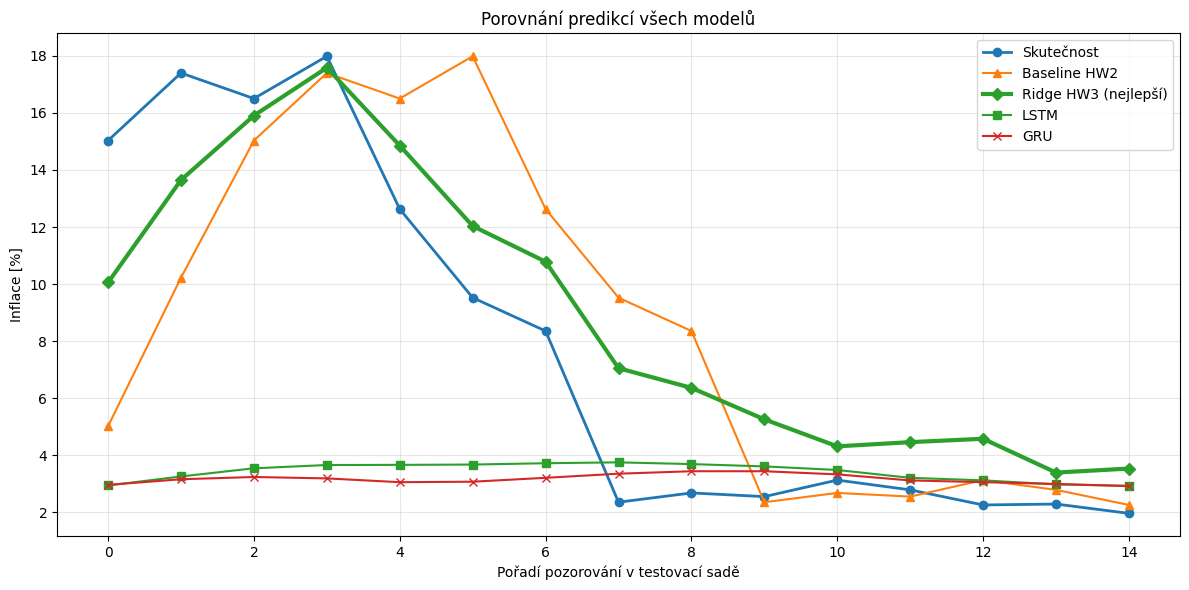

In [115]:
# Společné porovnání predikcí všech modelů

plt.figure(figsize=(12,6))

plt.plot(
    y_test_aligned,
    marker="o",
    linewidth=2,
    label="Skutečnost"
)

plt.plot(
    baseline_pred_aligned,
    marker="^",
    label="Baseline HW2"
)

plt.plot(
    ridge_pred_aligned,
    marker="D",
    linewidth=3,
    color="tab:green",
    label="Ridge HW3 (nejlepší)"
)

plt.plot(
    lstm_predictions,
    marker="s",
    label="LSTM"
)

plt.plot(
    gru_predictions,
    marker="x",
    label="GRU"
)

plt.title("Porovnání predikcí všech modelů")
plt.xlabel("Pořadí pozorování v testovací sadě")
plt.ylabel("Inflace [%]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ?????smayat>><<<<



## 9. Přehled výsledků na testovací sadě

Následující tabulka je hlavním finálním porovnáním modelů. Řazení je podle `test_RMSE`, tedy podle chyby na testovací sadě.

In [116]:
comparison = pd.DataFrame({
    "Skutečnost": y_test_aligned,
    "Baseline": baseline_pred_aligned,
    "Ridge": ridge_pred_aligned,
    "LSTM": lstm_predictions,
    "GRU": gru_predictions
})

display(comparison.head(10))

,Skutečnost,Baseline,Ridge,LSTM,GRU
0,15.029760,5.019695,10.055705,2.944449,2.965236
1,17.395742,10.225083,13.646401,3.259887,3.161869
2,16.500666,15.029760,15.903343,3.545853,3.241177
3,17.982128,17.395742,17.580591,3.660519,3.191876
4,12.628350,16.500666,14.851305,3.665895,3.059165
5,9.523526,17.982128,12.033562,3.677035,3.076217
6,8.356501,12.628350,10.785072,3.723293,3.212430
7,2.358153,9.523526,7.053390,3.753961,3.356548
8,2.682374,8.356501,6.364039,3.693397,3.442621
9,2.554291,2.358153,5.260814,3.612110,3.442786


In [107]:
final_table = results_df[[
    "model", "test_MAE", "test_RMSE", "test_R2", "train_RMSE", "overfit_gap_RMSE"
]].copy()

final_table = final_table.sort_values("test_RMSE").reset_index(drop=True)
final_table

NameError: name 'results_df' is not defined

## 10. Grafické porovnání podle RMSE

In [ ]:
print(results_df.head())

In [ ]:
plt.figure(figsize=(12, 6))

colors = [
    "tab:red" if model == "Baseline_HW2"
    else "tab:blue"
    for model in final_table["model"]
]
bars = plt.bar(
    final_table["model"],
    final_table["test_MAE"],
    color=colors
)


plt.title("Porovnání modelů podle RMSE na testovací sadě")
plt.ylabel("RMSE [p. b. inflace]")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

# hodnoty nad sloupci
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

## 11. Grafické porovnání podle MAE

In [ ]:
plt.figure(figsize=(12, 6))

colors = [
    "tab:red" if model == "Baseline_HW2"
    else "tab:blue"
    for model in final_table["model"]
]
bars = plt.bar(
    final_table["model"],
    final_table["test_MAE"],
    color=colors
)

plt.title("Porovnání modelů podle MAE na testovací sadě")
plt.ylabel("MAE [p. b. inflace]")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

# hodnoty nad sloupci
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 12. Kontrola možného přeučení

Přeučení se může projevit tak, že model má velmi nízkou chybu na trénovacích datech, ale výrazně horší chybu na testovacích datech.

In [ ]:
overfit_table = results_df[[
    "model", "train_RMSE", "test_RMSE", "overfit_gap_RMSE"
]].sort_values("overfit_gap_RMSE", ascending=False)

overfit_table

In [ ]:
plot_overfit = overfit_table.sort_values("overfit_gap_RMSE", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_overfit["model"], plot_overfit["overfit_gap_RMSE"])
plt.title("Rozdíl mezi testovací a trénovací RMSE")
plt.ylabel("Test RMSE - Train RMSE")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Porovnání skutečných a predikovaných hodnot

V grafu porovnávám skutečnou inflaci v následujícím kvartálu s predikcí nejlepšího modelu podle testovací RMSE.

In [ ]:
results_df.sort_values("test_RMSE").plot(
    x="model",
    y="test_RMSE",
    kind="bar",
    figsize=(10,5),
    title="Porovnání modelů podle RMSE"
)
plt.show()

In [ ]:
best_model_name = results_df.sort_values("test_RMSE").iloc[0]["model"]

if best_model_name == "Baseline_HW2":
    best_model_pred = baseline_test_pred
else:
    best_model_pred = predictions_test[best_model_name]

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, marker="o", label="Skutečnost")
plt.plot(y_test.index, best_model_pred, marker="o", label=f"Predikce: {best_model_name}")
plt.title(f"Skutečné vs. predikované hodnoty – {best_model_name}")
plt.ylabel("Inflace v následujícím kvartálu")
plt.xlabel("Datum")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Nejlepší model podle testovací RMSE:", best_model_name)

In [ ]:
results_df.sort_values("test_MAE").plot(
    x="model",
    y="test_MAE",
    kind="bar",
    figsize=(10,5),
    title="Porovnání modelů podle MAE"
)
plt.show()

In [ ]:
results_df.sort_values("test_R2").plot(
    x="model",
    y="test_R2",
    kind="bar",
    figsize=(10,5),
    title="Porovnání modelů podle R²"
)
plt.axhline(y=0, linestyle="--")
plt.show()

In [ ]:
results_df.plot(
    x="model",
    y=["train_RMSE","test_RMSE"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Train vs Test RMSE")
plt.show()

## 14. Porovnání s baseline modelem z HW2


In [ ]:
best_row = results_df.sort_values("test_RMSE").iloc[0]
baseline_row = results_df[results_df["model"] == "Baseline_HW2"].iloc[0]

absolute_improvement = baseline_row["test_RMSE"] - best_row["test_RMSE"]
relative_improvement = absolute_improvement / baseline_row["test_RMSE"] * 100

print("Nejlepší model:", best_row["model"])
print("RMSE nejlepšího modelu:", round(best_row["test_RMSE"], 4))
print("RMSE baseline z HW2:", round(baseline_row["test_RMSE"], 4))
print("Absolutní zlepšení RMSE:", round(absolute_improvement, 4))
print("Relativní zlepšení RMSE v %:", round(relative_improvement, 2))

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Baseline HW2", best_row["model"]],
    "RMSE": [
        baseline_row["test_RMSE"],
        best_row["test_RMSE"]
    ]
})

ax = comparison.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    figsize=(7,5),
    legend=False,
    title="Porovnání nejlepšího modelu s baseline z HW2"
)

plt.ylabel("RMSE [procentní body inflace]")
plt.xlabel("Model")
plt.grid(axis="y", alpha=0.3)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
metrics_plot = results_df.set_index("model")[
    ["test_MAE","test_RMSE","test_R2"]
]

metrics_plot.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Souhrnné porovnání modelů")
plt.show()

## 15. Diskuze výsledků
